In [1]:
%pip install datasphere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 212.3 kB/s  0:01:05m0:00:0200:03
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib_metadata 8.7.0
    Uninstalling importlib_metadata-8.7.0:
      Successfully uninstalled importlib_metadata-8.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [datasphere]8 [datasphere]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sip 6.12.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
xarray 2025.10.1 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib

import sys

sys.path.append("/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/2")

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/2/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

print("device:", device)


torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda


In [3]:
nu_values = [0.1, 0.01, 0.001]
dtype_values = ["fp32", "fp64"]
seed_values = [0, 1, 2]


def make_nu_tag(nu):
    s = f"{nu:.5g}"
    s = s.replace("-", "m")
    s = s.replace(".", "p")
    return s


final_config = {
    "task_name": "burgers1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "nu": nu_values[0],
    "hid_size": 64,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_ic": 500,
    "n_bc": 500,
    "adam_steps": 8000,
    "lbfgs_steps": 500,
    "lr_adam": 1e-3,
    "use_adam": True,
    "use_lbfgs": True,
    "log_dir": "/kaggle/working/runs/burgers1d_fp32_0",
}

In [4]:
all_summaries = []
all_histories = {}

for nu in nu_values:
    nu_tag = make_nu_tag(nu)
    for dtype in dtype_values:
        for seed in seed_values:
            config = final_config.copy()
            config["nu"] = nu
            config["dtype"] = dtype
            config["seed"] = seed
            config["log_dir"] = f"/kaggle/working/runs/burgers1d_nu_{nu_tag}_{dtype}_{seed}"
            history, summary = pinn_model.run_experiment(config)
            summary["nu"] = nu
            all_summaries.append(summary)
            all_histories[f"nu{nu_tag}_{dtype}_seed{seed}"] = history

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [5]:
df = pd.DataFrame(all_summaries)
if "nu" not in df.columns:
    df["nu"] = df["alpha"]

df = df.sort_values(["nu", "dtype", "seed"]).reset_index(drop=True)
df.to_csv("results_summary.csv", index=False)
df.to_csv("burgers_results_summary.csv", index=False)
df

,task_name,dtype,seed,alpha,hid_size,num_layers,n_collocation,n_ic,n_bc,adam_steps,lbfgs_steps,final_loss,final_l2_error,time_sec,log_dir,nu
0,burgers1d,fp32,0,0.001,64,4,5000,500,500,8000,500,0.038372,0.316188,101.542322,/kaggle/working/runs/burgers1d_nu_0p001_fp32_0,0.001
1,burgers1d,fp32,1,0.001,64,4,5000,500,500,8000,500,0.023884,0.230167,100.112102,/kaggle/working/runs/burgers1d_nu_0p001_fp32_1,0.001
2,burgers1d,fp32,2,0.001,64,4,5000,500,500,8000,500,0.035947,0.621321,98.871905,/kaggle/working/runs/burgers1d_nu_0p001_fp32_2,0.001
3,burgers1d,fp64,0,0.001,64,4,5000,500,500,8000,500,0.069690,0.395316,172.611696,/kaggle/working/runs/burgers1d_nu_0p001_fp64_0,0.001
4,burgers1d,fp64,1,0.001,64,4,5000,500,500,8000,500,0.509152,1.000001,170.023572,/kaggle/working/runs/burgers1d_nu_0p001_fp64_1,0.001
5,burgers1d,fp64,2,0.001,64,4,5000,500,500,8000,500,0.061692,0.395219,171.797577,/kaggle/working/runs/burgers1d_nu_0p001_fp64_2,0.001
6,burgers1d,fp32,0,0.010,64,4,5000,500,500,8000,500,0.000038,0.049333,100.153620,/kaggle/working/runs/burgers1d_nu_0p01_fp32_0,0.010
7,burgers1d,fp32,1,0.010,64,4,5000,500,500,8000,500,0.000040,0.049119,99.451127,/kaggle/working/runs/burgers1d_nu_0p01_fp32_1,0.010
8,burgers1d,fp32,2,0.010,64,4,5000,500,500,8000,500,0.000031,0.049273,98.924911,/kaggle/working/runs/burgers1d_nu_0p01_fp32_2,0.010
9,burgers1d,fp64,0,0.010,64,4,5000,500,500,8000,500,0.000045,0.049208,173.669000,/kaggle/working/runs/burgers1d_nu_0p01_fp64_0,0.010


In [6]:
grouped = df.groupby(["nu", "dtype"])[["final_l2_error", "final_loss", "time_sec"]].agg(["mean", "std"])
grouped.to_csv("results_grouped.csv")
grouped.to_csv("burgers_results_grouped.csv")
grouped

final_l2_error           final_loss              time_sec  \
                      mean       std       mean       std        mean   
nu    dtype                                                             
0.001 fp32        0.389225  0.205551   0.032734  0.007760  100.175443   
      fp64        0.596845  0.349143   0.213511  0.256063  171.477615   
0.010 fp32        0.049242  0.000110   0.000036  0.000005   99.509886   
      fp64        0.049239  0.000046   0.000039  0.000006  173.457550   
0.100 fp32        0.023617  0.000125   0.000010  0.000007  103.448357   
      fp64        0.023766  0.000085   0.000010  0.000003  173.245895   

                       
                  std  
nu    dtype            
0.001 fp32   1.336335  
      fp64   1.323396  
0.010 fp32   0.616458  
      fp64   0.200358  
0.100 fp32   3.618746  
      fp64   0.585047

In [7]:
from IPython.display import display

work_dir = Path('/kaggle/working')

if 'df' not in globals():
    df = pd.read_csv(work_dir / 'burgers_results_summary.csv')

if 'nu' not in df.columns:
    df['nu'] = df['alpha']

nu_values = sorted(df['nu'].unique())
dtype_values = sorted(df['dtype'].unique())
seed_values = sorted(df['seed'].unique())

df = df.sort_values(['nu', 'dtype', 'seed']).reset_index(drop=True)
display(df[['nu', 'dtype', 'seed', 'final_l2_error', 'final_loss', 'time_sec', 'log_dir']])

grouped = df.groupby(['nu', 'dtype'])[['final_l2_error', 'final_loss', 'time_sec']].agg(['mean', 'std'])
display(grouped)

best = df.loc[df['final_l2_error'].idxmin()]
display(best.to_frame('value'))

,nu,dtype,seed,final_l2_error,final_loss,time_sec,log_dir
0,0.001,fp32,0,0.316188,0.038372,101.542322,/kaggle/working/runs/burgers1d_nu_0p001_fp32_0
1,0.001,fp32,1,0.230167,0.023884,100.112102,/kaggle/working/runs/burgers1d_nu_0p001_fp32_1
2,0.001,fp32,2,0.621321,0.035947,98.871905,/kaggle/working/runs/burgers1d_nu_0p001_fp32_2
3,0.001,fp64,0,0.395316,0.069690,172.611696,/kaggle/working/runs/burgers1d_nu_0p001_fp64_0
4,0.001,fp64,1,1.000001,0.509152,170.023572,/kaggle/working/runs/burgers1d_nu_0p001_fp64_1
5,0.001,fp64,2,0.395219,0.061692,171.797577,/kaggle/working/runs/burgers1d_nu_0p001_fp64_2
6,0.010,fp32,0,0.049333,0.000038,100.153620,/kaggle/working/runs/burgers1d_nu_0p01_fp32_0
7,0.010,fp32,1,0.049119,0.000040,99.451127,/kaggle/working/runs/burgers1d_nu_0p01_fp32_1
8,0.010,fp32,2,0.049273,0.000031,98.924911,/kaggle/working/runs/burgers1d_nu_0p01_fp32_2
9,0.010,fp64,0,0.049208,0.000045,173.669000,/kaggle/working/runs/burgers1d_nu_0p01_fp64_0


final_l2_error           final_loss              time_sec  \
                      mean       std       mean       std        mean   
nu    dtype                                                             
0.001 fp32        0.389225  0.205551   0.032734  0.007760  100.175443   
      fp64        0.596845  0.349143   0.213511  0.256063  171.477615   
0.010 fp32        0.049242  0.000110   0.000036  0.000005   99.509886   
      fp64        0.049239  0.000046   0.000039  0.000006  173.457550   
0.100 fp32        0.023617  0.000125   0.000010  0.000007  103.448357   
      fp64        0.023766  0.000085   0.000010  0.000003  173.245895   

                       
                  std  
nu    dtype            
0.001 fp32   1.336335  
      fp64   1.323396  
0.010 fp32   0.616458  
      fp64   0.200358  
0.100 fp32   3.618746  
      fp64   0.585047

,value
task_name,burgers1d
dtype,fp32
seed,1
alpha,0.1
hid_size,64
num_layers,4
n_collocation,5000
n_ic,500
n_bc,500
adam_steps,8000


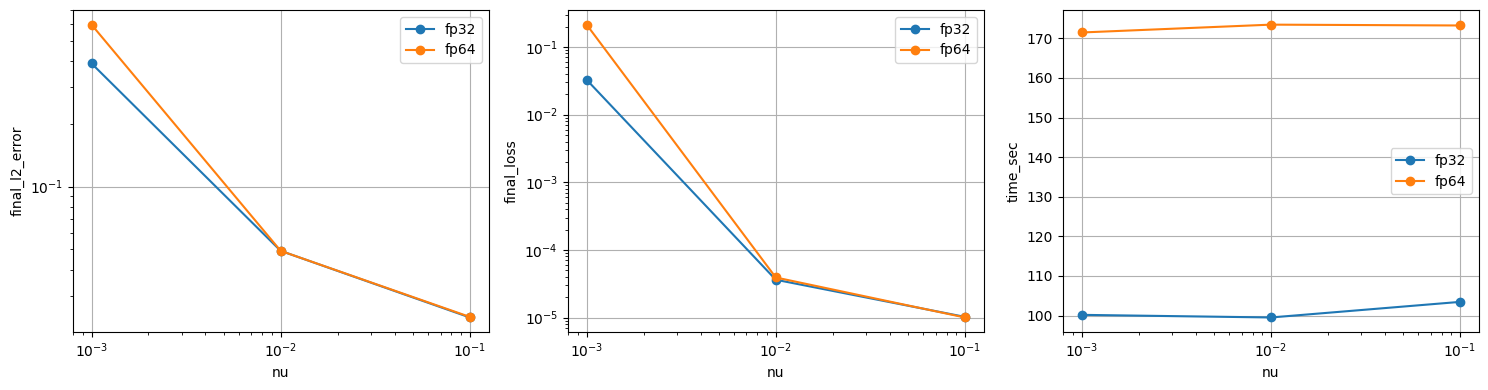

In [8]:
mean_df = df.groupby(['nu', 'dtype'])[['final_l2_error', 'final_loss', 'time_sec']].mean().reset_index()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for dtype in dtype_values:
    part = mean_df[mean_df['dtype'] == dtype].sort_values('nu')
    ax[0].plot(part['nu'], part['final_l2_error'], 'o-', label=dtype)
    ax[1].plot(part['nu'], part['final_loss'], 'o-', label=dtype)
    ax[2].plot(part['nu'], part['time_sec'], 'o-', label=dtype)

for a in ax:
    a.set_xscale('log')
    a.grid(True)
    a.set_xlabel('nu')
    a.legend()

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylabel('final_l2_error')
ax[1].set_ylabel('final_loss')
ax[2].set_ylabel('time_sec')

fig.tight_layout()
plt.show()

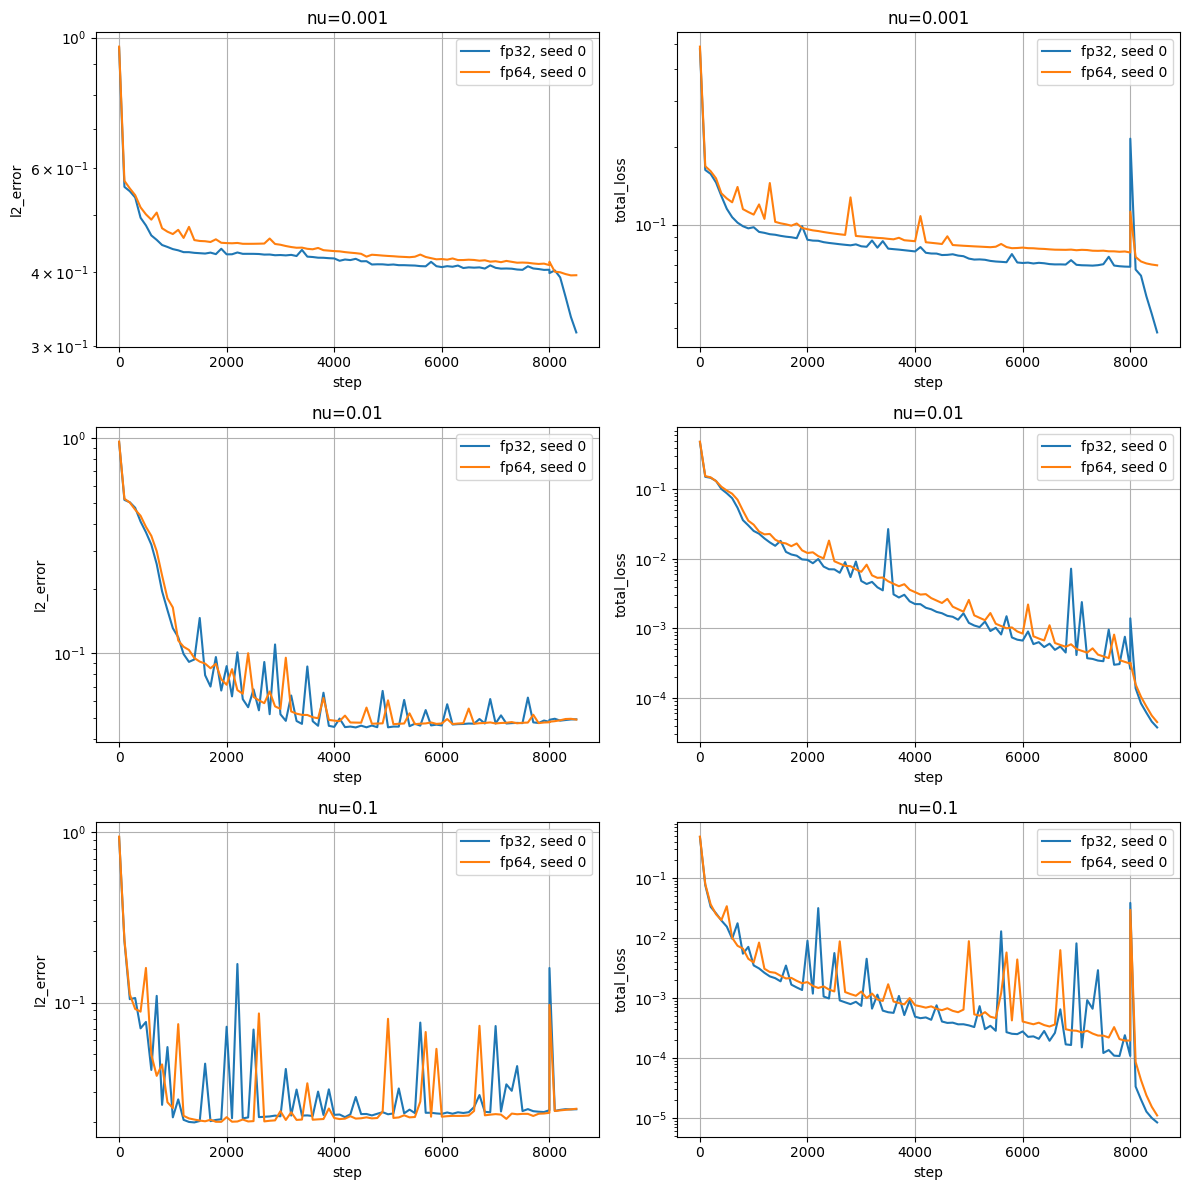

In [9]:
if 'make_nu_tag' not in globals():
    def make_nu_tag(nu):
        s = f"{nu:.5g}"
        s = s.replace("-", "m")
        s = s.replace(".", "p")
        return s

fig, ax = plt.subplots(len(nu_values), 2, figsize=(12, 4 * len(nu_values)))
ax = np.array(ax).reshape(len(nu_values), 2)

for i, nu in enumerate(nu_values):
    nu_tag = make_nu_tag(nu)
    for dtype in dtype_values:
        seed = seed_values[0]
        p = work_dir / 'runs' / f'burgers1d_nu_{nu_tag}_{dtype}_{seed}' / 'metrics.csv'
        if p.exists():
            h = pd.read_csv(p)
            label = f'{dtype}, seed {seed}'
            ax[i, 0].plot(h['step'], h['l2_error'], label=label)
            ax[i, 1].plot(h['step'], h['total_loss'], label=label)

    ax[i, 0].set_title(f'nu={nu:g}')
    ax[i, 1].set_title(f'nu={nu:g}')
    ax[i, 0].set_yscale('log')
    ax[i, 1].set_yscale('log')
    ax[i, 0].set_xlabel('step')
    ax[i, 1].set_xlabel('step')
    ax[i, 0].set_ylabel('l2_error')
    ax[i, 1].set_ylabel('total_loss')
    ax[i, 0].grid(True)
    ax[i, 1].grid(True)
    ax[i, 0].legend()
    ax[i, 1].legend()

fig.tight_layout()
plt.show()

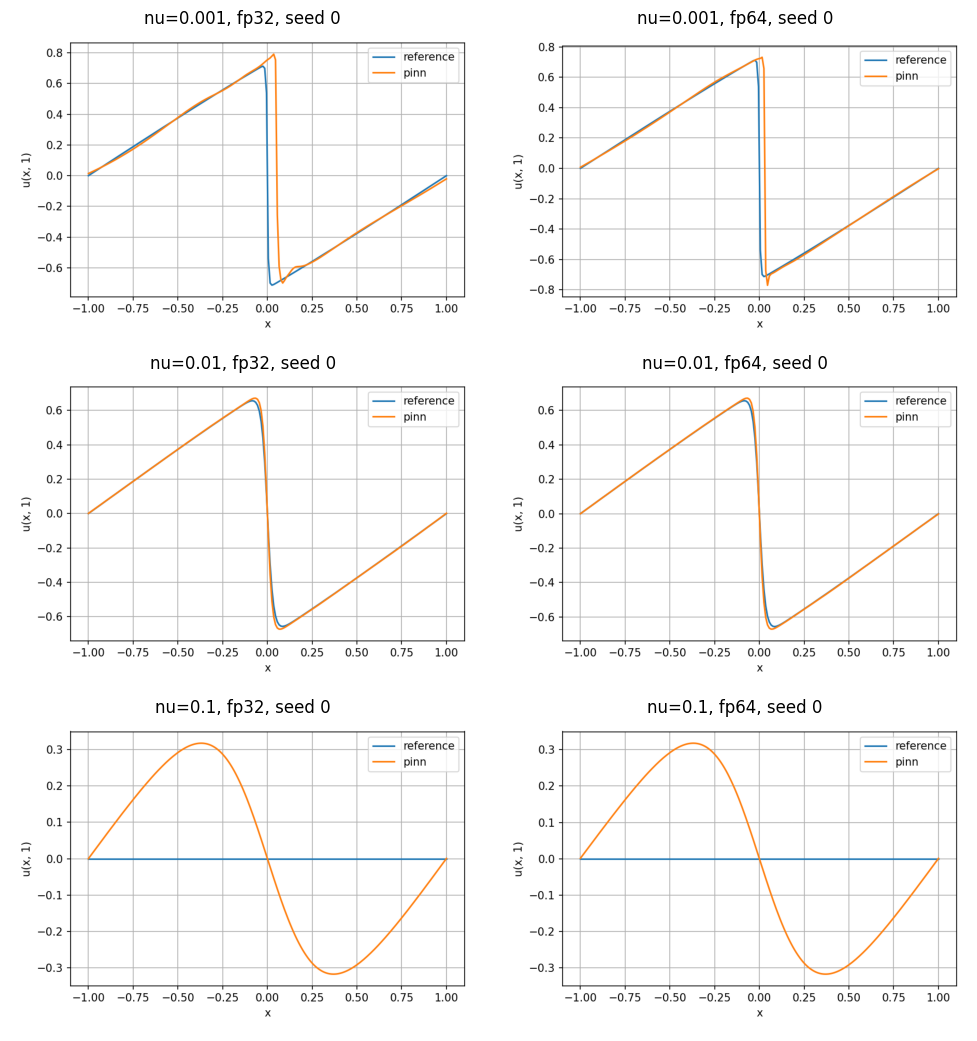

In [10]:
if 'make_nu_tag' not in globals():
    def make_nu_tag(nu):
        s = f"{nu:.5g}"
        s = s.replace("-", "m")
        s = s.replace(".", "p")
        return s

fig, ax = plt.subplots(len(nu_values), len(dtype_values), figsize=(5 * len(dtype_values), 3.5 * len(nu_values)))
ax = np.array(ax).reshape(len(nu_values), len(dtype_values))

for i, nu in enumerate(nu_values):
    nu_tag = make_nu_tag(nu)
    for j, dtype in enumerate(dtype_values):
        seed = seed_values[0]
        p = work_dir / 'runs' / f'burgers1d_nu_{nu_tag}_{dtype}_{seed}' / 'solution_t1.png'
        ax[i, j].set_title(f'nu={nu:g}, {dtype}, seed {seed}')
        ax[i, j].axis('off')
        if p.exists():
            img = plt.imread(p)
            ax[i, j].imshow(img)

fig.tight_layout()
plt.show()